# Linear Regression from Scratch

This notebook walks through the same linear regression logic used in `main.py`, but broken
into small steps so you can see what each part is doing.

Instead of using a library like `scikit-learn` or `numpy.polyfit` to fit the line, we compute
the slope and intercept manually using the **least-squares formula**. The goal is to build
intuition for how linear regression actually works under the hood.

We'll use `counting-data.csv`, which has two columns: `Number` and `NextNumber` (mostly
`NextNumber = Number + 1`, with a little noise in one row).

Run the cells below in order.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_FILE = Path("counting-data.csv")

## Load the Data

Read the CSV into a pandas DataFrame and take a look at it.

In [20]:
raw_data = pd.read_csv(DATA_FILE)
raw_data

,Number,NextNumber
0,0,1.000
1,1,2.000
2,3,4.000
3,100,101.000
4,115,116.000
5,-10,-9.999


## Clean the Data

Real-world data is often messy. Here we make sure both columns are numeric, and drop any
rows that can't be converted (`errors="coerce"` turns bad values into `NaN`, which `dropna()`
then removes).

In [21]:
data = raw_data[["Number", "NextNumber"]].apply(pd.to_numeric, errors="coerce").dropna()
data

,Number,NextNumber
0,0,1.000
1,1,2.000
2,3,4.000
3,100,101.000
4,115,116.000
5,-10,-9.999


## Split into Training and Test Sets

To check how well our fitted line generalizes, we split the data in half: the first half is
used to **train** (fit) the model, and the second half is held out as **test** data to see
how the line does on points it hasn't "seen."

In [22]:
split_index = len(data) // 2

training_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

x_train = training_data["Number"]
y_train = training_data["NextNumber"]

print(f"Training rows: {len(training_data)}")
print(f"Test rows: {len(test_data)}")

Training rows: 3
Test rows: 3


## Fit the Line: The Least-Squares Formula

We want to find a line `NextNumber = slope * Number + intercept` that best fits the training
points. The classic least-squares solution is:

$$
\text{slope} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
$$

$$
\text{intercept} = \bar{y} - \text{slope} \cdot \bar{x}
$$

In words:
- Center `x` and `y` around their means (`x - x_mean`, `y - y_mean`).
- The slope is the ratio of how `x` and `y` vary *together* (numerator) to how much `x`
  varies on its own (denominator).
- The intercept just shifts the line so it passes through the point `(x_mean, y_mean)`.

In [23]:
x_mean = x_train.mean()
y_mean = y_train.mean()

centered_x = x_train - x_mean
denominator = (centered_x**2).sum()

slope = (centered_x * (y_train - y_mean)).sum() / denominator
intercept = y_mean - slope * x_mean

print(f"Linear regression: NextNumber = {slope:.4f} * Number + {intercept:.4f}")

Linear regression: NextNumber = 1.0000 * Number + 1.0000


## Interpreting the Result

For this dataset, `NextNumber` is basically always `Number + 1`, so you should see a slope
close to `1` and an intercept close to `1`. If a row has a slightly different value (like the
`-10, -9.999` row), it will pull the fit ever so slightly away from a perfect `slope=1,
intercept=1`.

## Visualize the Fit

Plot the training points (blue), the held-out test points (orange), and the fitted
regression line (red) extended a bit beyond the data range.

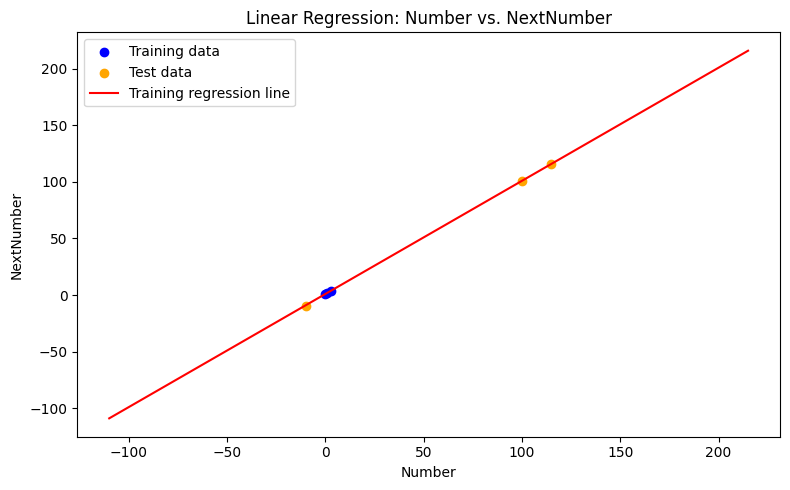

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(
    training_data["Number"],
    training_data["NextNumber"],
    label="Training data",
    color="blue",
)
plt.scatter(
    test_data["Number"],
    test_data["NextNumber"],
    label="Test data",
    color="orange",
)

line_x = pd.Series([data["Number"].min() - 100, data["Number"].max() + 100])
line_y = slope * line_x + intercept
plt.plot(
    line_x,
    line_y,
    color="red",
    label="Training regression line",
)

plt.xlabel("Number")
plt.ylabel("NextNumber")
plt.title("Linear Regression: Number vs. NextNumber")
plt.legend()
plt.tight_layout()
plt.show()

## Part 2: A Noisier Dataset & R²

The `counting-data.csv` points are almost perfectly linear, so the fit above is nearly
perfect too — not very interesting for judging "how good" a fit is. To make that
meaningful, we'll generate a second dataset that's linear **on average** but has random
noise added to each point, using `numpy` with a fixed seed so it's reproducible.

We'll fit a line to this noisy data the same way as before, then compute **R²** (the
coefficient of determination) to measure how well the line explains the data.

In [25]:
import numpy as np

rng = np.random.default_rng(seed=42)

n_points = 40
true_slope = 1.0
true_intercept = 1.0
noise_scale = 4.0

x_noisy = np.linspace(0, 100, n_points)
y_true = true_slope * x_noisy + true_intercept
noise = rng.normal(loc=0.0, scale=noise_scale, size=n_points)
y_noisy = y_true + noise

noisy_data = pd.DataFrame({"Number": x_noisy, "NextNumber": y_noisy})
noisy_data.head()

,Number,NextNumber
0,0.000000,2.218868
1,2.564103,-0.595834
2,5.128205,9.130010
3,7.692308,12.454567
4,10.256410,3.452270


### Split and Fit the Noisy Data

Same approach as before: split into training/test, then compute the slope and intercept
with the least-squares formula. We use `_noisy` suffixes so these don't overwrite the
`slope`/`intercept` from the original data above.

In [26]:
split_index_noisy = len(noisy_data) // 2

training_data_noisy = noisy_data.iloc[:split_index_noisy]
test_data_noisy = noisy_data.iloc[split_index_noisy:]

x_train_noisy = training_data_noisy["Number"]
y_train_noisy = training_data_noisy["NextNumber"]

x_mean_noisy = x_train_noisy.mean()
y_mean_noisy = y_train_noisy.mean()

centered_x_noisy = x_train_noisy - x_mean_noisy
denominator_noisy = (centered_x_noisy**2).sum()

slope_noisy = (centered_x_noisy * (y_train_noisy - y_mean_noisy)).sum() / denominator_noisy
intercept_noisy = y_mean_noisy - slope_noisy * x_mean_noisy

print(f"Noisy linear regression: NextNumber = {slope_noisy:.4f} * Number + {intercept_noisy:.4f}")
print(f"(True underlying line was: NextNumber = {true_slope:.4f} * Number + {true_intercept:.4f})")

Noisy linear regression: NextNumber = 1.0396 * Number + -0.0963
(True underlying line was: NextNumber = 1.0000 * Number + 1.0000)


### What is R²?

**R² (the coefficient of determination)** measures how much of the variation in `y` is
explained by our fitted line, on a scale from 0 to 1 (it can even go negative for a very
bad fit):

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

- $SS_{res} = \sum (y_i - \hat{y}_i)^2$ — the **residual** sum of squares: how far actual
  points are from our predictions $\hat{y}_i$ (the leftover error the line *doesn't*
  explain).
- $SS_{tot} = \sum (y_i - \bar{y})^2$ — the **total** sum of squares: how far actual points
  are from the simple average $\bar{y}$ (i.e., how much the data varies at all).

Intuition:
- $R^2 = 1$: predictions match the data perfectly, no leftover error.
- $R^2 = 0$: the line does no better than just predicting the average $\bar{y}$ every time.
- Somewhere in between: the closer to 1, the more of the data's variation the line explains.

In [27]:
def r_squared(y_true_values, y_predicted_values) -> float:
    """Compute the coefficient of determination (R²) for a set of predictions."""
    y_true_values = pd.Series(y_true_values)
    y_predicted_values = pd.Series(y_predicted_values)
    ss_res = ((y_true_values - y_predicted_values) ** 2).sum()
    ss_tot = ((y_true_values - y_true_values.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot


# R² on the original (near-perfect) test data
original_test_predictions = slope * test_data["Number"] + intercept
r2_original = r_squared(test_data["NextNumber"], original_test_predictions)

# R² on the noisy test data
noisy_test_predictions = slope_noisy * test_data_noisy["Number"] + intercept_noisy
r2_noisy = r_squared(test_data_noisy["NextNumber"], noisy_test_predictions)

print(f"R² on original test data: {r2_original:.4f}")
print(f"R² on noisy test data:    {r2_noisy:.4f}")

R² on original test data: 0.9999
R² on noisy test data:    0.9458


### Visualize the Noisy Fit

Same plotting approach as before. Notice how the points scatter around the red line
instead of sitting right on it — that scatter is exactly what R² is quantifying.

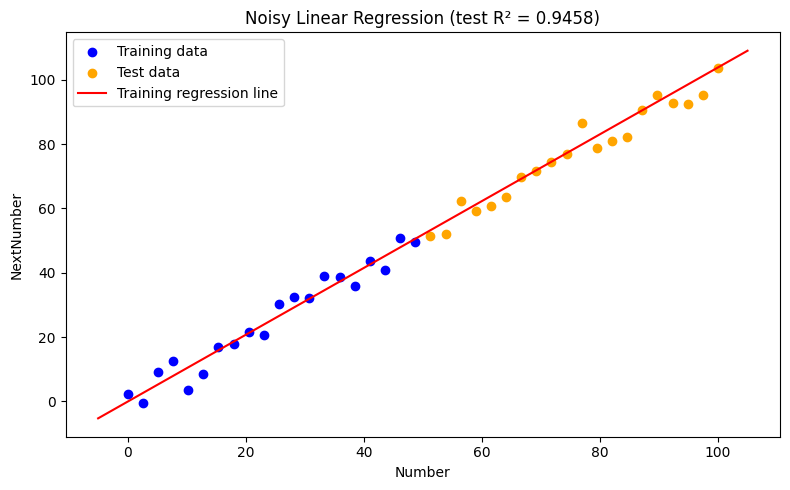

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(
    training_data_noisy["Number"],
    training_data_noisy["NextNumber"],
    label="Training data",
    color="blue",
)
plt.scatter(
    test_data_noisy["Number"],
    test_data_noisy["NextNumber"],
    label="Test data",
    color="orange",
)

line_x_noisy = pd.Series([noisy_data["Number"].min() - 5, noisy_data["Number"].max() + 5])
line_y_noisy = slope_noisy * line_x_noisy + intercept_noisy
plt.plot(
    line_x_noisy,
    line_y_noisy,
    color="red",
    label="Training regression line",
)

plt.xlabel("Number")
plt.ylabel("NextNumber")
plt.title(f"Noisy Linear Regression (test R² = {r2_noisy:.4f})")
plt.legend()
plt.tight_layout()
plt.show()

### What Are Residuals?

A **residual** is just the leftover error for a single point: the difference between what
actually happened and what the line predicted.

$$
\text{residual}_i = y_i - \hat{y}_i
$$

where $y_i$ is the actual value and $\hat{y}_i = \text{slope} \cdot x_i + \text{intercept}$
is the line's prediction for that same $x_i$. This is exactly the piece that gets squared
and summed up to make $SS_{res}$ in the R² formula above — R² is really just a summary of
"how big are the residuals, overall?"

Residuals are useful to look at on their own (not just squared and summed) because their
*pattern* tells you things a single R² number can't:
- Scattered randomly around zero, no shape → the line is a reasonable fit, and any noise
  looks like genuine randomness.
- A clear curve, funnel, or trend in the residuals → the relationship probably isn't
  actually linear, or the noise isn't uniform — the model is missing something.

A **residual plot** puts $x$ on the horizontal axis and the residual on the vertical axis,
with a flat line at zero representing "no error." Points near that line are good
predictions; points far from it are the ones the line got wrong.

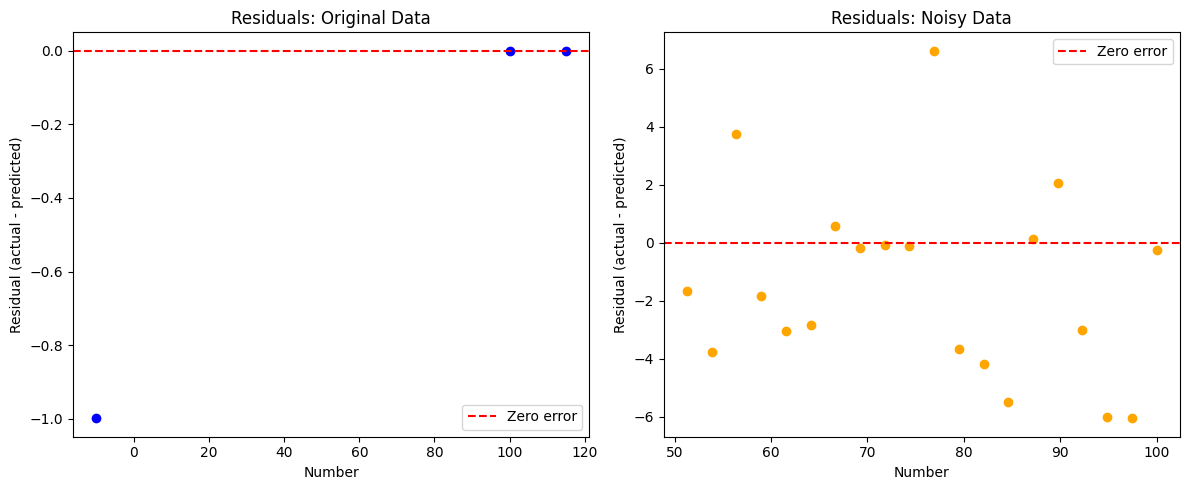

In [29]:
# Residuals = actual - predicted, computed for the test data of each dataset
residuals_original = test_data["NextNumber"] - original_test_predictions
residuals_noisy = test_data_noisy["NextNumber"] - noisy_test_predictions

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

axes[0].scatter(test_data["Number"], residuals_original, color="blue")
axes[0].axhline(0, color="red", linestyle="--", label="Zero error")
axes[0].set_xlabel("Number")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals: Original Data")
axes[0].legend()

axes[1].scatter(test_data_noisy["Number"], residuals_noisy, color="orange")
axes[1].axhline(0, color="red", linestyle="--", label="Zero error")
axes[1].set_xlabel("Number")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals: Noisy Data")
axes[1].legend()

plt.tight_layout()
plt.show()

### Reading the Residual Plots

- **Original data (left):** residuals should be tiny and hug the zero line — the fit is
  nearly perfect, matching the very high R² you saw earlier.
- **Noisy data (right):** residuals should be scattered above and below zero with no
  obvious pattern (no curve, no funnel shape). That random scatter is a good sign — it means
  the *line itself* is a reasonable model, and what's left over really is just noise, not a
  missed pattern.

Try changing `noise_scale` back in Part 2 and re-running everything from there down — you'll
see the residual scatter get wider (or narrower) along with the R² value changing.

## Wrap-Up & Things to Try

This is the same math `main.py` uses, just spelled out step-by-step, plus a look at R² using
a synthetic noisy dataset. Some ideas for experimenting further:

- Change `split_index` (e.g., use a 70/30 split instead of 50/50) and see how the line changes.
- Add more rows to `counting-data.csv` with some intentional noise, and watch the slope drift
  away from `1`.
- Compare this manual fit to `numpy.polyfit(x_train, y_train, 1)` or
  `sklearn.linear_model.LinearRegression` — they should give (nearly) the same slope and
  intercept.
- Try computing the *test* error (e.g., mean squared error between predicted and actual
  `NextNumber` on `test_data`) to see how well the fit generalizes.
- Change `noise_scale` in Part 2 (try `1.0` vs `10.0` vs `20.0`) and re-run to see how R²
  drops as the data gets noisier — this is a great way to build intuition for what different
  R² values actually look like.
- Try a different `n_points` or a different `true_slope`/`true_intercept` to see the fit
  still recovers values close to the truth even with noise.